# 3.1 — KV cache deep dive

```text
1 why / mental model
→ 2 with vs without (real metrics)
→ 3 what is stored (shapes, bytes, HBM)
→ 4 prefill write / decode read on GPU
→ 5 prefix reuse (HF — same model, no second load)
→ 6 paged KV (vLLM — last; can be heavy)
```

Model: `Qwen2.5-7B` via `local_paths` (`QWEN_MODEL`).

**Run All tip:** this notebook loads a large model. If Cursor says *notebook controller is DISPOSED*,
the kernel died (usually VRAM). Prefer **Run Above / cell-by-cell** for §6 (vLLM), or free the GPU first.
HF sections (§0–§5) are safe to Run All together.


## 1 — Why KV cache exists

At each decode step the model must attend over *all previous tokens*.

Without a cache, every step **recomputes** Key/Value for the whole sequence → step time grows with length.

```text
step t:  Attention(Q_t,  K_1..K_t,  V_1..V_t)
         └─ without cache: recompute K/V for 1..t every time  (≈ O(t) growing)
         └─ with cache:    read K/V_1..t-1 from HBM, compute only K/V_t
```

K and V for token *i* are **fixed** once computed in that context — so storing them is correct, not an approximation.


## 0 — Setup


In [1]:
import gc
import os
import sys
import time
from pathlib import Path
from statistics import mean, median

# Pin GPU before torch CUDA init (change to 3 if needed)
GPU_ID = int(os.environ.get("CUDA_DEVICE", "2"))
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_ID)

import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "local_paths.py").is_file():
        sys.path.insert(0, str(p))
        break

from local_paths import model_path

MODEL = str(model_path("QWEN_MODEL"))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROMPT = "Write a short introduction about the US capital city."
print("MODEL =", MODEL)
print("DEVICE =", DEVICE, "| GPU =", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "n/a")
print("PROMPT =", PROMPT)
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))

tokenizer = AutoTokenizer.from_pretrained(MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    trust_remote_code=True,
).to(DEVICE).eval()

cfg = model.config
print(
    f"layers={cfg.num_hidden_layers}  hidden={cfg.hidden_size}  "
    f"heads={cfg.num_attention_heads}  kv_heads={getattr(cfg, 'num_key_value_heads', cfg.num_attention_heads)}  "
    f"head_dim={cfg.hidden_size // cfg.num_attention_heads}"
)


/home/mbrdiuser/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL = /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-7B
DEVICE = cuda | GPU = Tesla V100-SXM2-32GB
PROMPT = Write a short introduction about the US capital city.
CUDA_VISIBLE_DEVICES = 2


Loading checkpoint shards: 100%|██████████| 4/4 [00:01<00:00,  2.08it/s]


layers=28  hidden=3584  heads=28  kv_heads=4  head_dim=128


## 2 — With vs without (make the gap *visible*)

### Why your first run looked flat

On a tiny model, short-context step times can look flat either way. Attention is a small slice of the forward; **kernel launch + FFN** dominate. So `use_cache=False` vs `True` in a short generate loop barely moves.

That does **not** mean KV is useless — it means we must measure the right thing.

### Better experiment (two curves)

1. **Full recompute forward** at length `L` — `model(ids_L, use_cache=False)`  
   → time should **grow** with `L` (must rebuild K/V for all tokens).

2. **Cached decode** at the same `L` — prefill once to length `L`, then time **one** new-token forward with `past_key_values`  
   → time stays **much flatter**.

Also plot **cumulative work** to generate `N` new tokens starting from prompt length `P`:
- without cache ≈ cost of forwards at lengths `P+1 … P+N` (grows like a triangle)
- with cache ≈ one prefill(`P`) + `N` × decode


In [2]:
# --- Intuitive A/B: time vs context length (not a short generate loop) ---
LENGTHS = [128, 256, 512, 1024, 1536]
N_WARM = 2
N_REP = 5
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

def make_ids(L: int) -> torch.Tensor:
    # fixed random-ish tokens in vocab (deterministic)
    g = torch.Generator(device="cpu").manual_seed(0)
    ids = torch.randint(100, 1000, (1, L), generator=g)
    return ids.to(DEVICE)


@torch.inference_mode()
def time_full_forward(L: int) -> float:
    ids = make_ids(L)
    for _ in range(N_WARM):
        _ = model(ids, use_cache=False)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(N_REP):
        _ = model(ids, use_cache=False)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) * 1000 / N_REP


@torch.inference_mode()
def time_cached_decode(L: int) -> float:
    """Build KV for L tokens, then time ONLY the next-token forward (past reused)."""
    ids = make_ids(L)
    nxt = torch.tensor([[100]], device=DEVICE)
    samples = []
    for i in range(N_WARM + N_REP):
        past = model(ids, use_cache=True).past_key_values  # not timed
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(nxt, use_cache=True, past_key_values=past)  # timed: 1-token decode
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        dt = (time.perf_counter() - t0) * 1000
        if i >= N_WARM:
            samples.append(dt)
    return mean(samples)


full_ms = []
decode_ms = []
print(f"{'L':>6}  {'full_recompute_ms':>18}  {'cached_decode_ms':>16}  {'ratio full/dec':>14}")
print("-" * 60)
for L in LENGTHS:
    f = time_full_forward(L)
    d = time_cached_decode(L)
    full_ms.append(f)
    decode_ms.append(d)
    print(f"{L:6d}  {f:18.1f}  {d:16.1f}  {f/d:14.2f}x")

print("""
READ THIS TABLE
---------------
- full_recompute_ms should rise with L  (no KV: pay for whole sequence every time)
- cached_decode_ms stays flatter        (KV: pay mostly for 1 new token + bandwidth to read cache)
- ratio >> 1 at large L = why serving always uses a KV cache
""")


     L   full_recompute_ms  cached_decode_ms  ratio full/dec
------------------------------------------------------------


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)


   128                58.6              30.8            1.90x
   256                67.5              30.9            2.18x
   512               108.1              30.3            3.56x
  1024               210.9              32.0            6.59x
  1536               313.0              33.9            9.22x

READ THIS TABLE
---------------
- full_recompute_ms should rise with L  (no KV: pay for whole sequence every time)
- cached_decode_ms stays flatter        (KV: pay mostly for 1 new token + bandwidth to read cache)
- ratio >> 1 at large L = why serving always uses a KV cache



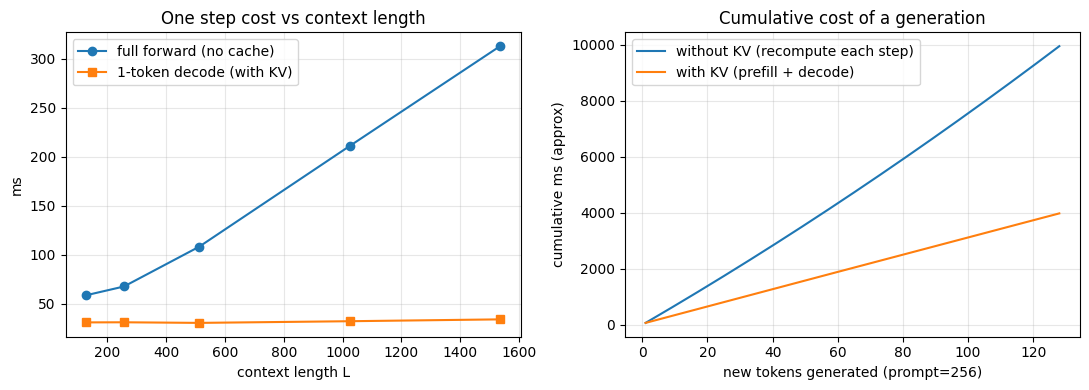

approx wall to generate 128 tok from prompt 256:
  WITHOUT KV  ~ 9951 ms
  WITH KV     ~ 3978 ms
  speedup     ~ 2.5x


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(LENGTHS, full_ms, "o-", label="full forward (no cache)")
ax.plot(LENGTHS, decode_ms, "s-", label="1-token decode (with KV)")
ax.set_xlabel("context length L")
ax.set_ylabel("ms")
ax.set_title("One step cost vs context length")
ax.legend()
ax.grid(alpha=0.3)

# Cumulative cost to generate N new tokens from prompt length P
P, N = 256, 128


def interp(xs, ys, x):
    if x <= xs[0]:
        return ys[0]
    if x >= xs[-1]:
        x0, x1 = xs[-2], xs[-1]
        y0, y1 = ys[-2], ys[-1]
        return y1 + (y1 - y0) * (x - x1) / (x1 - x0)
    for i in range(1, len(xs)):
        if x <= xs[i]:
            x0, x1 = xs[i - 1], xs[i]
            y0, y1 = ys[i - 1], ys[i]
            t = (x - x0) / (x1 - x0)
            return y0 + t * (y1 - y0)
    return ys[-1]


# without: at step k (seq = P+k) pay full forward ~ interp(P+k)
cum_no = []
cum_yes = []
s_no = s_yes = 0.0
prefill = interp(LENGTHS, full_ms, P)  # prefill ~ full forward at P (with cache write; similar order)
for k in range(1, N + 1):
    s_no += interp(LENGTHS, full_ms, P + k)
    cum_no.append(s_no)
    if k == 1:
        s_yes += prefill  # first step = prefill
    else:
        s_yes += interp(LENGTHS, decode_ms, P + k - 1)
    cum_yes.append(s_yes)

ax = axes[1]
ax.plot(range(1, N + 1), cum_no, label="without KV (recompute each step)")
ax.plot(range(1, N + 1), cum_yes, label="with KV (prefill + decode)")
ax.set_xlabel(f"new tokens generated (prompt={P})")
ax.set_ylabel("cumulative ms (approx)")
ax.set_title("Cumulative cost of a generation")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"approx wall to generate {N} tok from prompt {P}:")
print(f"  WITHOUT KV  ~ {cum_no[-1]:.0f} ms")
print(f"  WITH KV     ~ {cum_yes[-1]:.0f} ms")
print(f"  speedup     ~ {cum_no[-1]/cum_yes[-1]:.1f}x")


## 3 — What is stored (layout + bytes)

For **each layer**, for **each past token**, the model stores:

- **K** — shape roughly `[batch, num_kv_heads, seq, head_dim]`
- **V** — same shape

Qwen2.5 uses **GQA** (`num_key_value_heads` ≤ `num_attention_heads`): fewer KV heads than query heads → smaller cache.

### Bytes per token (one sequence)

```text
bytes/token ≈ 2 (K+V) × num_layers × num_kv_heads × head_dim × sizeof(dtype)
```

That lives in **GPU HBM**. Decode reads it every step → often **memory-bandwidth bound**, not math bound.



In [4]:
n_layers = cfg.num_hidden_layers
n_kv = getattr(cfg, "num_key_value_heads", cfg.num_attention_heads)
n_heads = cfg.num_attention_heads
head_dim = cfg.hidden_size // n_heads
dtype_bytes = 2  # fp16

bytes_per_tok = 2 * n_layers * n_kv * head_dim * dtype_bytes
print(f"num_layers          = {n_layers}")
print(f"num_attention_heads = {n_heads}")
print(f"num_kv_heads (GQA)  = {n_kv}")
print(f"head_dim            = {head_dim}")
print(f"bytes / token       = {bytes_per_tok}  ({bytes_per_tok/1024:.2f} KiB)")
print()
for ctx in (512, 1024, 2048, 4096, 8192):
    mb = bytes_per_tok * ctx / (1024 ** 2)
    print(f"  ctx={ctx:5d} tok  →  KV ≈ {mb:7.1f} MiB / sequence")

print()
print("If max_num_seqs=8 and max_model_len=4096 (all full):")
print(f"  pool ≈ {8 * bytes_per_tok * 4096 / (1024**2):.0f} MiB  (upper bound; real engines page + share)")

num_layers          = 28
num_attention_heads = 28
num_kv_heads (GQA)  = 4
head_dim            = 128
bytes / token       = 57344  (56.00 KiB)

  ctx=  512 tok  →  KV ≈    28.0 MiB / sequence
  ctx= 1024 tok  →  KV ≈    56.0 MiB / sequence
  ctx= 2048 tok  →  KV ≈   112.0 MiB / sequence
  ctx= 4096 tok  →  KV ≈   224.0 MiB / sequence
  ctx= 8192 tok  →  KV ≈   448.0 MiB / sequence

If max_num_seqs=8 and max_model_len=4096 (all full):
  pool ≈ 1792 MiB  (upper bound; real engines page + share)


## 4 — Prefill write / decode read (GPU view)

```text
HBM
 ┌─────────────────────────────────────────────┐
 │  weights (fixed)                            │
 │  KV cache pool  ←── prefill WRITES all      │
 │                 ←── decode APPENDS 1 token  │
 │                 ←── decode READS all past   │
 └─────────────────────────────────────────────┘
              ▲                │
              │  load W + KV   │  store new K/V
         ┌────┴────┐      ┌────▼────┐
         │   SMs   │      │   SMs   │
         │ compute │      │ compute │
         └─────────┘      └─────────┘
```

| Phase | Input tokens this step | KV traffic | Binding |
|-------|------------------------|------------|---------|
| **Prefill** | all prompt tokens | **write** full prompt KV | usually **compute**-heavy (big matmuls) |
| **Decode** | 1 new token | **read** past KV + **write** 1 | often **bandwidth**-heavy |

Inspect HF `past_key_values` after prefill vs after a few decode steps.


In [5]:
@torch.inference_mode()
def peek_cache(prompt: str, n_decode: int = 5):
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    out = model(ids, use_cache=True)
    past = out.past_key_values
    # past: tuple[n_layers] of (k, v)
    k0, v0 = past[0]
    print(f"after prefill  seq={ids.shape[1]}")
    print(f"  layer0 K shape = {tuple(k0.shape)}   # [B, kv_heads, seq, head_dim]")
    print(f"  layer0 V shape = {tuple(v0.shape)}")
    print(f"  n_layers in cache = {len(past)}")
    nbytes = sum(k.numel() * k.element_size() + v.numel() * v.element_size() for k, v in past)
    print(f"  total KV bytes    = {nbytes}  ({nbytes/1024:.1f} KiB)  vs formula {bytes_per_tok * ids.shape[1]}")

    next_id = int(torch.argmax(out.logits[:, -1, :], dim=-1).item())
    cur = torch.tensor([[next_id]], device=DEVICE)
    for i in range(n_decode - 1):
        out = model(cur, use_cache=True, past_key_values=past)
        past = out.past_key_values
        next_id = int(torch.argmax(out.logits[:, -1, :], dim=-1).item())
        cur = torch.tensor([[next_id]], device=DEVICE)

    k0, v0 = past[0]
    print(f"after +{n_decode} decode  seq={k0.shape[2]}")
    print(f"  layer0 K shape = {tuple(k0.shape)}  ← seq dim grew")
    nbytes = sum(k.numel() * k.element_size() + v.numel() * v.element_size() for k, v in past)
    print(f"  total KV bytes    = {nbytes}  ({nbytes/1024:.1f} KiB)")

peek_cache(PROMPT, n_decode=8)


after prefill  seq=10
  layer0 K shape = (1, 4, 10, 128)   # [B, kv_heads, seq, head_dim]
  layer0 V shape = (1, 4, 10, 128)
  n_layers in cache = 28
  total KV bytes    = 573440  (560.0 KiB)  vs formula 573440
after +8 decode  seq=17
  layer0 K shape = (1, 4, 17, 128)  ← seq dim grew
  total KV bytes    = 974848  (952.0 KiB)


## 5 — Advanced: prefix reuse (HF)

Same idea as automatic prefix caching, shown with HuggingFace `past_key_values`:

```text
MISS:  forward(system + question)
HIT:   past = forward(system);  forward(question, past=past)
```

Runs on the model already loaded in setup — **no second GPU load**.


In [6]:
# Prefix reuse on the SAME HF `model` from setup (no second load).
SYSTEM = ("You are a careful assistant. Answer in one short sentence. " * 40)
QUESTIONS = [
    "What is a KV cache?",
    "What is PagedAttention?",
    "What is prefill vs decode?",
]

sys_ids = tokenizer(SYSTEM, return_tensors="pt").input_ids.to(DEVICE)
print(f"system tokens = {sys_ids.shape[1]}")


@torch.inference_mode()
def ttft_full(system: str, question: str) -> float:
    ids = tokenizer(system + "\nUser: " + question, return_tensors="pt").input_ids.to(DEVICE)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = model(ids, use_cache=True)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) * 1000


@torch.inference_mode()
def ttft_prefix_hit(sys_past, question: str) -> float:
    q_ids = tokenizer("\nUser: " + question, return_tensors="pt").input_ids.to(DEVICE)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = model(q_ids, use_cache=True, past_key_values=sys_past)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) * 1000


with torch.inference_mode():
    sys_past = model(sys_ids, use_cache=True).past_key_values

print(f"\n{'question':28s} {'MISS full_ms':>12s} {'HIT prefix_ms':>14s} {'speedup':>8s}")
print("-" * 70)
miss_list, hit_list = [], []
for q in QUESTIONS:
    miss = ttft_full(SYSTEM, q)
    hit = ttft_prefix_hit(sys_past, q)
    miss_list.append(miss)
    hit_list.append(hit)
    print(f"{q:28s} {miss:12.1f} {hit:14.1f} {miss/hit:8.2f}x")

print(
    f"\nmedian MISS {median(miss_list):.1f} ms | median HIT {median(hit_list):.1f} ms | "
    f"speedup {median(miss_list)/median(hit_list):.2f}x"
)
print("HIT << MISS → reusing prefix KV avoids recomputing the long system prompt.")


system tokens = 481

question                     MISS full_ms  HIT prefix_ms  speedup
----------------------------------------------------------------------
What is a KV cache?                 106.5           34.3     3.11x
What is PagedAttention?             106.7           33.6     3.18x
What is prefill vs decode?          106.9           33.5     3.19x

median MISS 106.7 ms | median HIT 33.6 ms | speedup 3.18x
HIT << MISS → reusing prefix KV avoids recomputing the long system prompt.


## 6 — Paged KV (vLLM)

**Run this section last.** It frees the HF model and starts vLLM on the same GPU.

If *Run All* dies here with *controller DISPOSED*, re-run from this cell alone after a kernel restart,
or lower `gpu_memory_utilization` below.

PagedAttention: fixed-size **blocks** + **block table** (like OS virtual memory).


In [7]:
import gc
import time

# --- Tear down HF model completely before vLLM (avoids Run-All OOM / kernel DISPOSED) ---
for _name in ("model", "past", "sys_past"):
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass

gc.collect()
if DEVICE == "cuda":
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass
    time.sleep(2)
    free, total = torch.cuda.mem_get_info(0)
    print(f"VRAM before vLLM: free={free/1024**3:.1f}/{total/1024**3:.1f} GiB")

from vllm import SamplingParams
from vllm.engine.arg_utils import AsyncEngineArgs
from vllm.engine.async_llm_engine import AsyncLLMEngine

# Slightly conservative util so init is less likely to abort the kernel
engine_args = AsyncEngineArgs(
    model=MODEL,
    dtype="float16",
    enforce_eager=True,
    gpu_memory_utilization=0.75,
    max_model_len=2048,
    max_num_seqs=4,
    enable_prefix_caching=False,
)
try:
    engine = AsyncLLMEngine.from_engine_args(engine_args)
except Exception as e:
    print("vLLM failed to start (kernel may still be alive):", type(e).__name__, e)
    engine = None
    raise

inner = getattr(engine, "engine", engine)
print("engine class:", type(inner))
for attr in ("cache_config", "scheduler_config"):
    obj = getattr(inner, attr, None)
    if obj is None:
        continue
    print(f"\n{attr}:")
    for k in ("block_size", "gpu_memory_utilization", "num_gpu_blocks", "enable_prefix_caching",
              "max_model_len", "max_num_seqs", "max_num_batched_tokens"):
        if hasattr(obj, k):
            print(f"  {k} = {getattr(obj, k)}")


VRAM before vLLM: free=30.8/31.7 GiB


2026-09-25 14:39:03,176	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


WARNING 09-25 14:39:04 config.py:1657] Casting torch.bfloat16 to torch.float16.
WARNING 09-25 14:39:04 config.py:383] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 09-25 14:39:04 llm_engine.py:223] Initializing an LLM engine (v0.6.1.post1) with config: model='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-7B', speculative_config=None, tokenizer='/home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-7B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, rope_scaling=None, rope_theta=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=True, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_dec

/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/mbrdiuser/miniconda3/envs/vllm_lab/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")


INFO 09-25 14:39:05 model_runner.py:997] Starting to load model /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-7B...
INFO 09-25 14:39:05 selector.py:217] Cannot use FlashAttention-2 backend for Volta and Turing GPUs.
INFO 09-25 14:39:05 selector.py:116] Using XFormers backend.


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:02,  1.06it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:02<00:02,  1.06s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:03<00:01,  1.10s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:04<00:00,  1.12s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:04<00:00,  1.09s/it]



INFO 09-25 14:39:10 model_runner.py:1008] Loading model weights took 14.2716 GB
INFO 09-25 14:39:10 gpu_executor.py:122] # GPU blocks: 10002, # CPU blocks: 4681
engine class: <class 'vllm.engine.async_llm_engine._AsyncLLMEngine'>

cache_config:
  block_size = 16
  gpu_memory_utilization = 0.75
  num_gpu_blocks = 10002
  enable_prefix_caching = False

scheduler_config:
  max_model_len = 2048
  max_num_seqs = 4
  max_num_batched_tokens = 2048


In [8]:
import asyncio
import uuid

async def timed_generate(prompt: str, max_tokens: int = 64):
    sp = SamplingParams(temperature=0.0, max_tokens=max_tokens)
    t0 = time.perf_counter()
    ttft = None
    n = 0
    text = ""
    async for out in engine.generate(prompt, sp, request_id=str(uuid.uuid4())):
        n = len(out.outputs[0].token_ids)
        text = out.outputs[0].text
        if ttft is None and n >= 1:
            ttft = time.perf_counter() - t0
    e2e = time.perf_counter() - t0
    return {"ttft_s": ttft, "e2e_s": e2e, "n_tok": n, "tok_s": n / e2e if e2e else 0, "text": text}


async def run_vllm_baseline():
    # warmup
    await timed_generate("warmup", 8)
    r = await timed_generate(PROMPT, 64)
    print("vLLM (paged KV, prefix_caching=OFF)")
    print(f"  TTFT={r['ttft_s']*1000:.1f} ms  e2e={r['e2e_s']*1000:.1f} ms  "
          f"n={r['n_tok']}  tok/s={r['tok_s']:.1f}")
    print("  text:", r["text"][:160].replace("\n", " "))

await run_vllm_baseline()


INFO 09-25 14:39:14 async_llm_engine.py:201] Added request a5ffe087-5163-4a9d-9122-bcdde3660dd3.
INFO 09-25 14:39:14 async_llm_engine.py:169] Finished request a5ffe087-5163-4a9d-9122-bcdde3660dd3.
INFO 09-25 14:39:14 async_llm_engine.py:201] Added request 29cf732a-0eaf-4b34-a4e4-65362360215b.
INFO 09-25 14:39:15 async_llm_engine.py:169] Finished request 29cf732a-0eaf-4b34-a4e4-65362360215b.
vLLM (paged KV, prefix_caching=OFF)
  TTFT=42.7 ms  e2e=1583.5 ms  n=64  tok/s=40.4
  text:  Washington D.C. is the capital city of the United States of America. It is located on the Potomac River and is home to many important government buildings, inc


## 7 — Mental model checklist

```text
1. Attention needs K/V for every past token every step.
2. Cache them in HBM → decode step cost stays ~flat; memory grows with tokens × layers × kv_heads.
3. Prefill = build cache (write). Decode = read cache + append one.
4. Serving engines page the cache (blocks) so many requests share one GPU pool.
5. Advanced: reuse blocks across requests (prefix), shrink dtype, or spill cold blocks off-GPU.
```

| Metric | Without KV | With KV | Prefix hit |
|--------|------------|---------|------------|
| step time vs length | rises | flat decode | flat |
| TTFT | = first full forward | prefill of prompt | often ≪ full prefill |
| HBM | mostly weights | weights + growing KV | KV shared across reqs |

### What to try next
- Sweep prompt length: plot no-cache vs cache median step ms  
- Raise `max_model_len` / concurrency until KV pool exhausts (OOM or preemption)  
- Topic 8 later: deliberate KV offload latency spikes
